<a href="https://colab.research.google.com/github/anamikasarker21/AI-ML/blob/main/Cancer_restNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
import seaborn as sns

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 50
data = []
labels = []

train_dir = '/content/drive/MyDrive/melanoma_cancer_dataset/train'
test_dir = '/content/drive/MyDrive/melanoma_cancer_dataset/test'

In [ ]:
for category in os.listdir(train_dir):
    path = os.path.join(train_dir, category)
    label = 0 if category == 'benign' else 1

    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            data.append(img)
            labels.append(label)
        except:
            pass

In [ ]:
X = np.array(data, dtype='float32') / 255.0
y = np.array(labels)

print(X.shape)

(9622, 128, 128, 3)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

In [ ]:
def augment_image(img):

    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)

    angle = np.random.randint(-20, 20)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))

    return img

In [ ]:
def data_generator(X, y, batch_size=32):

    while True:
        idx = np.random.randint(0, len(X), batch_size)

        batch_X = np.zeros((batch_size, IMG_SIZE, IMG_SIZE, 3), dtype='float32')
        batch_y = np.zeros((batch_size,))

        for i, j in enumerate(idx):
            img = X[j]

            # 50% augmentation
            if np.random.rand() < 0.5:
                img = augment_image(img)

            batch_X[i] = img
            batch_y[i] = y[j]

        yield batch_X, batch_y

In [ ]:
train_gen = data_generator(X_train, y_train, BATCH_SIZE)
val_gen   = data_generator(X_val, y_val, BATCH_SIZE)

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [ ]:
history = model.fit(
    train_gen,
    steps_per_epoch=100,
    validation_data=(X_val, y_val),
    validation_steps=20,
    epochs=EPOCHS
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.5175 - loss: 0.7015 - val_accuracy: 0.5670 - val_loss: 0.6701
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.5956 - loss: 0.6629 - val_accuracy: 0.5701 - val_loss: 0.6613
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.6300 - loss: 0.6494 - val_accuracy: 0.7321 - val_loss: 0.6405
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.6416 - loss: 0.6332 - val_accuracy: 0.7124 - val_loss: 0.6188
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.6497 - loss: 0.6163 - val_accuracy: 0.6791 - val_loss: 0.6025
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.7113 - loss: 0.5882 - val_accuracy: 0.6978 - val_loss: 0.5856
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.7075 - loss: 0.5779 - val_accuracy: 0.7414 - val_loss: 0.5737
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.7231 - loss: 0.5591 - val_accu

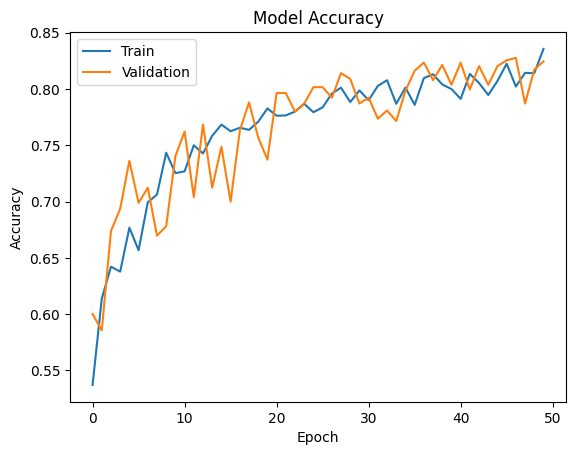

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


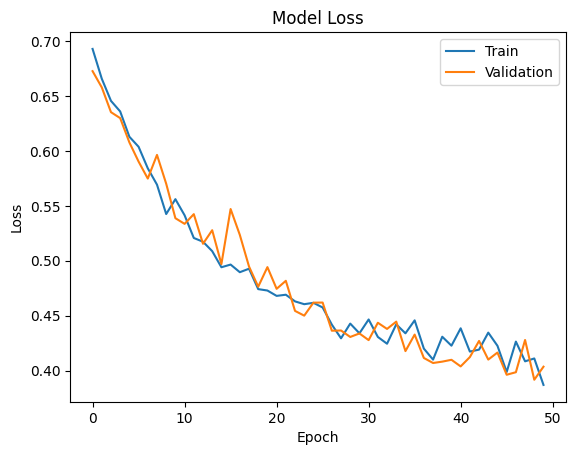

In [ ]:
# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
test_data = []
test_labels = []

In [ ]:
for category in os.listdir(test_dir):
    path = os.path.join(test_dir, category)
    label = 0 if category == 'benign' else 1

    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            test_data.append(img)
            test_labels.append(label)
        except:
            pass

In [ ]:
X_test = np.array(test_data, dtype='float32') / 255.0
y_test = np.array(test_labels)

print(X_test.shape)

(1020, 128, 128, 3)


In [ ]:
# Evaluate the model on the test data
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy on test data: %.2f%%" % (scores[1]*100))
print("Test loss: %.2f" % (scores[0]))

Accuracy on test data: 84.71%
Test loss: 0.38


In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84       500
           1       0.82      0.90      0.86       520

    accuracy                           0.85      1020
   macro avg       0.85      0.85      0.85      1020
weighted avg       0.85      0.85      0.85      1020



In [ ]:
from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy  : {accuracy  * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall    * 100:.2f}%")
print(f"F1 Score  : {f1        * 100:.2f}%")

Accuracy  : 84.71%
Precision : 85.07%
Recall    : 84.71%
F1 Score  : 84.65%


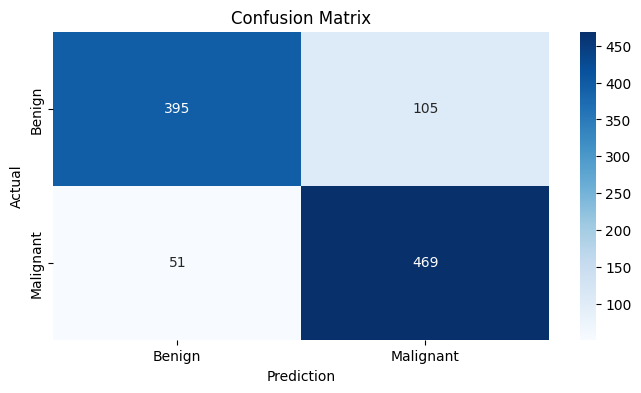

In [ ]:
confusionmatrics = confusion_matrix(y_test, y_pred)
labels = ['Benign', 'Malignant']
plt.figure(figsize=(8,4))
sns.heatmap(
    confusionmatrics,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
roc = roc_auc_score(y_test, y_pred)
print(f"ROC_AUC  : {roc  * 100:.2f}%")

ROC_AUC  : 84.60%
